# Single Hospital Patient Allocation Model

This notebook implements a Linear Programming model for optimizing patient admissions in a single hospital using ESI priority scoring.

---

## 1. Setup & Environment
Install and import necessary libraries.

In [21]:
%pip install pulp

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from pulp import LpMaximize, LpProblem, LpVariable, lpSum, value, PULP_CBC_CMD
sns.set_theme(style="whitegrid")

Note: you may need to restart the kernel to use updated packages.


## 2. Data Ingestion
Load hospital and patient data.

In [22]:
hospitals_df = pd.read_excel("Book1.xlsx").dropna(subset=['Hôpital'])
patients_df = pd.read_excel("patients_1000_ULTRA_COMPLET.xlsx")

# Clean numeric columns
hospitals_df['Lits totaux'] = pd.to_numeric(hospitals_df['Lits totaux'], errors='coerce').fillna(0)

print(f"Loaded {len(hospitals_df)} hospitals and {len(patients_df)} patients.")

Loaded 20 hospitals and 1000 patients.


## 3. Single Hospital Allocation Model
Linear Programming model for assigning patients to one hospital.

- **Decision Variable**: $x_p$ is 1 if patient $p$ is admitted, 0 otherwise.
- **Objective**: Maximize $\sum (6 - \text{ESI}_p) \times x_p$.
- **Constraint**: $\sum x_p \leq$ hospital capacity.

In [23]:
def solve_single_hospital_allocation(batch_patients, hospital_capacity):
    prob = LpProblem("Single_Hospital_Allocation", LpMaximize)
    
    p_idx = list(range(len(batch_patients)))
    
    # Binary Decision Variables
    x = LpVariable.dicts("admit", p_idx, cat="Binary")
    
    # Weighted Objective Function
    prob += lpSum(x[i] * (6 - batch_patients.iloc[i]['ESI']) for i in p_idx)
    
    # Constraint: Hospital capacity
    prob += lpSum(x[i] for i in p_idx) <= hospital_capacity
        
    prob.solve(PULP_CBC_CMD(msg=0))
    return x

print("Single hospital allocation engine initialized.")

Single hospital allocation engine initialized.


## 4. Simulation & Analysis
Simulate patient arrivals and admissions over time.

Selected hospital: Centre Hospitalier Universitaire Yalgado Ouédraogo with capacity 800.0 beds.


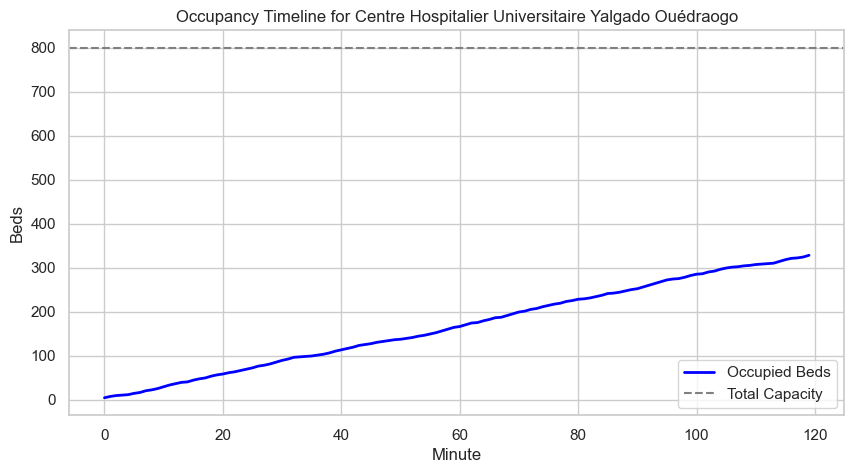

In [24]:
# Select a single hospital (e.g., the largest one)
single_hospital = hospitals_df.loc[hospitals_df['Lits totaux'].idxmax()]
hospital_name = single_hospital['Hôpital']
capacity = single_hospital['Lits totaux']

print(f"Selected hospital: {hospital_name} with capacity {capacity} beds.")

# Simulate 120 minutes
single_history = []
occupied = 0

for minute in range(120):
    new_patients = patients_df.sample(random.randint(1, 4))
    assignments = solve_single_hospital_allocation(new_patients, capacity - occupied)
    
    admitted_count = 0
    for i in range(len(new_patients)):
        if value(assignments[i]) == 1:
            occupied += 1
            admitted_count += 1
    
    single_history.append({"minute": minute, "occupied": occupied, "admitted_this_minute": admitted_count})

single_history_df = pd.DataFrame(single_history)

plt.figure(figsize=(10, 5))
plt.plot(single_history_df['minute'], single_history_df['occupied'], label='Occupied Beds', color='blue', lw=2)
plt.axhline(y=capacity, color='gray', linestyle='--', label='Total Capacity')
plt.title(f'Occupancy Timeline for {hospital_name}')
plt.xlabel('Minute')
plt.ylabel('Beds')
plt.legend()
plt.show()

## 5. Saturation Scenario Without Time Simulation
In this scenario, the hospital is already saturated: there are no free beds left. We test how the linear programming model behaves when a new batch of patients arrives but the hospital cannot admit anyone.

- **Hospital capacity available = 0**: the model cannot admit any patient.
- **All patients are refused**: the decision is equivalent to `x_p = 0` for all patients.
- **What this shows**: the capacity constraint is prioritized, even if very urgent patients (ESI=1) are present.

This is purely a static saturation test, without any time-based admission process.

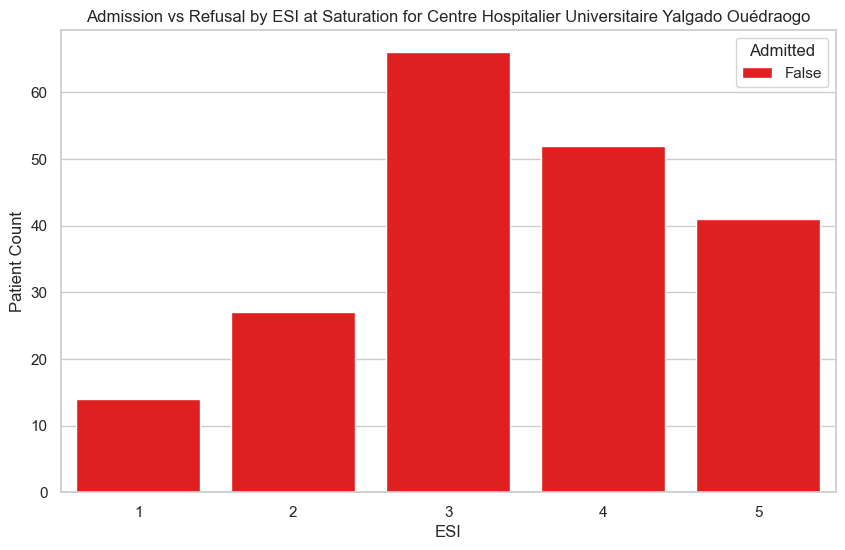

C:\Users\HP\AppData\Local\Temp\ipykernel_40604\2363736681.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=admission_rates, x='ESI', y='Admitted', palette='coolwarm')


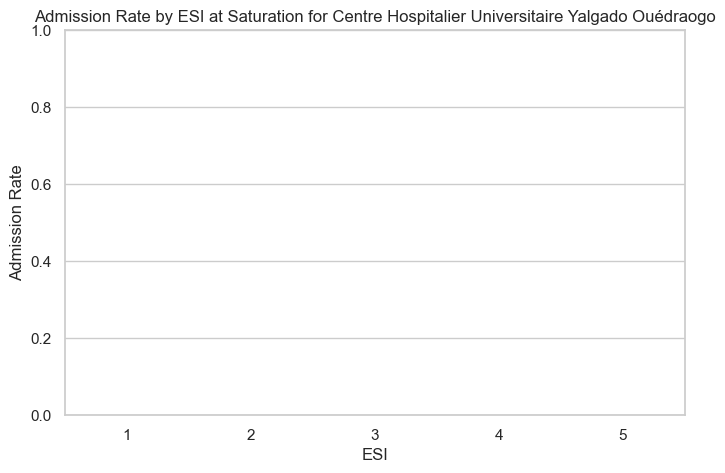

Saturation evaluation results for Centre Hospitalier Universitaire Yalgado Ouédraogo:
- Total Patients: 200
- Admitted Patients: 0
- Admission Rate: 0.000
- Average ESI (Admitted): nan
- Average ESI (Refused): 3.395
- Weighted Priority Score: 0


In [25]:
# Saturation scenario without time simulation
sat_batch = patients_df.sample(200, replace=True)
sat_capacity = 0  # hospital has no free beds at this instant
sat_assignments = solve_single_hospital_allocation(sat_batch, sat_capacity)

single_admission_results = []
for i in range(len(sat_batch)):
    admitted = value(sat_assignments[i]) == 1
    single_admission_results.append({"ESI": sat_batch.iloc[i]['ESI'], "Admitted": admitted})

single_res_df = pd.DataFrame(single_admission_results)

plt.figure(figsize=(10, 6))
sns.countplot(data=single_res_df, x='ESI', hue='Admitted', palette={True: "green", False: "red"})
plt.title(f'Admission vs Refusal by ESI at Saturation for {hospital_name}')
plt.xlabel('ESI')
plt.ylabel('Patient Count')
plt.legend(title='Admitted')
plt.show()

admission_rates = single_res_df.groupby('ESI')['Admitted'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=admission_rates, x='ESI', y='Admitted', palette='coolwarm')
plt.title(f'Admission Rate by ESI at Saturation for {hospital_name}')
plt.xlabel('ESI')
plt.ylabel('Admission Rate')
plt.ylim(0, 1)
plt.show()

# Evaluation metrics
single_metrics = {
    'Total Patients': len(single_res_df),
    'Admitted Patients': single_res_df['Admitted'].sum(),
    'Admission Rate': single_res_df['Admitted'].mean(),
    'Average ESI (Admitted)': single_res_df[single_res_df['Admitted']]['ESI'].mean(),
    'Average ESI (Refused)': single_res_df[~single_res_df['Admitted']]['ESI'].mean(),
    'Weighted Priority Score': single_res_df[single_res_df['Admitted']]['ESI'].apply(lambda x: 6 - x).sum(),
}

print(f'Saturation evaluation results for {hospital_name}:')
for k, v in single_metrics.items():
    if isinstance(v, float):
        print(f'- {k}: {v:.3f}')
    else:
        print(f'- {k}: {v}')

## 6. Overload Scenario: Extreme Surcharge
In this scenario, we load a massive number of patients (far exceeding hospital capacity) to observe how the Linear Programming model prioritizes admissions.

- **Patients loaded**: significantly more than hospital capacity.
- **Goal**: Observe if the model prioritizes urgent cases (low ESI) over stable cases (high ESI).
- **Key insight**: Under extreme overload, the model should admit only the highest-priority patients and refuse lower-priority ones.


=== OVERLOAD SCENARIO ===
Total patients loaded: 2400
Hospital capacity: 800 beds
Overload ratio: 3.00x hospital capacity
Admitted: 800
Refused: 1600



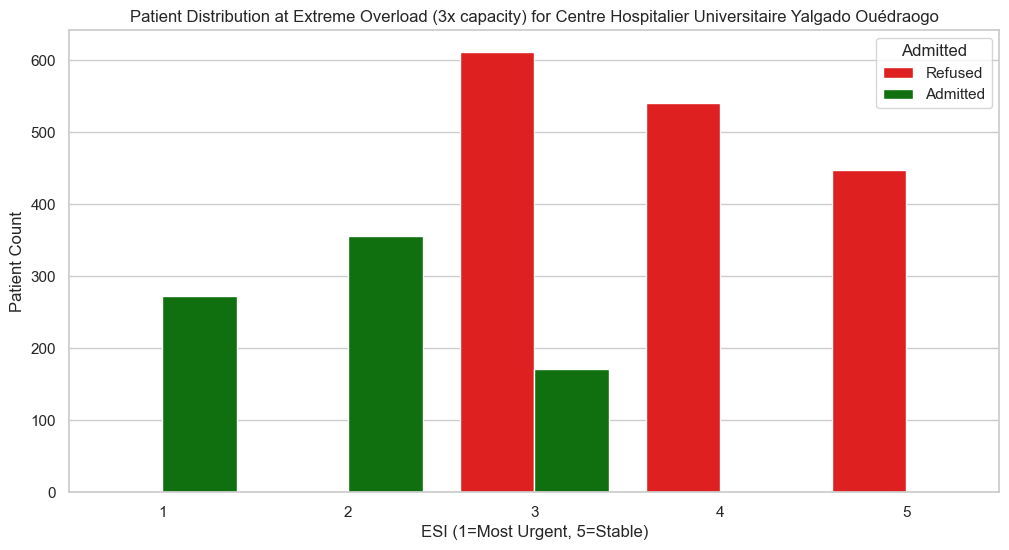

C:\Users\HP\AppData\Local\Temp\ipykernel_40604\657977558.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=admission_rates_overload, x='ESI', y='Admission Rate', palette='RdYlGn_r')


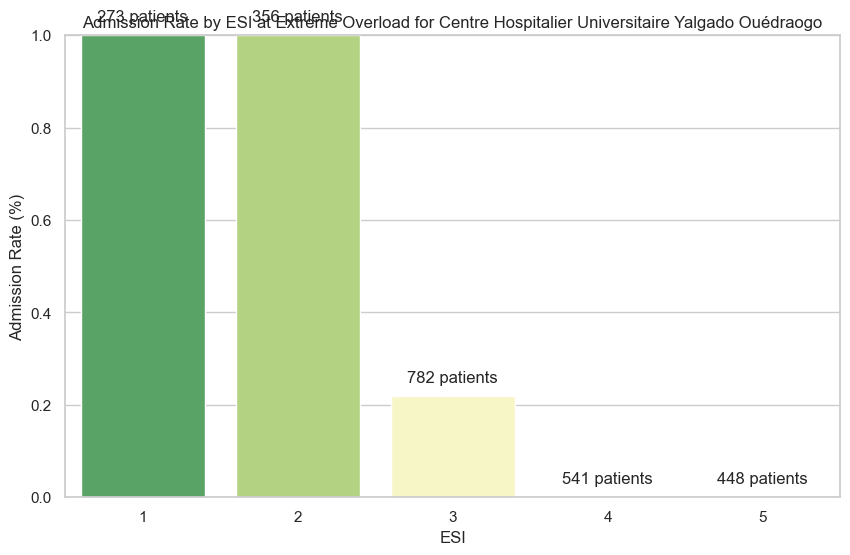

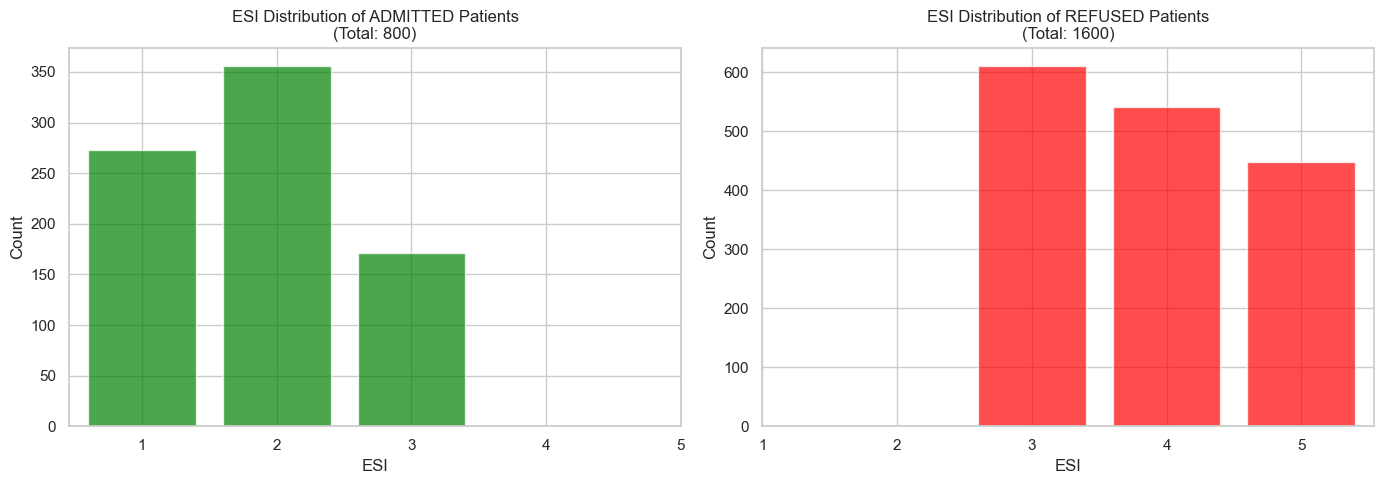

=== OVERLOAD EVALUATION RESULTS ===
- Total Patients: 2400
- Admitted Patients: 800
- Admission Rate (%): 33.333
- Average ESI (Admitted): 1.873
- Average ESI (Refused): 3.898
- ESI 1 Admission Rate: 1.000
- ESI 5 Admission Rate: 0.000
- Weighted Priority Score: 3302


In [ ]:
# Overload scenario: load patients far exceeding hospital capacity
overload_batch = patients_df.sample(int(capacity * 3), replace=True)  # 3x hospital capacity
overload_assignments = solve_single_hospital_allocation(overload_batch, int(capacity))

overload_admission_results = []
for i in range(len(overload_batch)):
    admitted = value(overload_assignments[i]) == 1
    overload_admission_results.append({"ESI": overload_batch.iloc[i]['ESI'], "Admitted": admitted})

overload_res_df = pd.DataFrame(overload_admission_results)

print(f'\n=== OVERLOAD SCENARIO ===')
print(f'Total patients loaded: {len(overload_res_df)}')
print(f'Hospital capacity: {int(capacity)} beds')
print(f'Overload ratio: {len(overload_res_df) / int(capacity):.2f}x hospital capacity')
print(f'Admitted: {overload_res_df["Admitted"].sum()}')
print(f'Refused: {(~overload_res_df["Admitted"]).sum()}\n')

# Graph 1: Admitted vs Refused by ESI
plt.figure(figsize=(12, 6))
sns.countplot(data=overload_res_df, x='ESI', hue='Admitted', palette={True: "green", False: "red"})
plt.title(f'Patient Distribution at Extreme Overload (3x capacity) for {hospital_name}')
plt.xlabel('ESI (1=Most Urgent, 5=Stable)')
plt.ylabel('Patient Count')
plt.legend(title='Admitted', labels=['Refused', 'Admitted'])
plt.tight_layout()
plt.show()

# Graph 2: Admission rate by ESI
admission_rates_overload = overload_res_df.groupby('ESI')['Admitted'].agg(['mean', 'count']).reset_index()
admission_rates_overload.columns = ['ESI', 'Admission Rate', 'Total']

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=admission_rates_overload, x='ESI', y='Admission Rate', palette='RdYlGn_r')
plt.title(f'Admission Rate by ESI at Extreme Overload for {hospital_name}')
plt.xlabel('ESI')
plt.ylabel('Admission Rate (%)')
plt.ylim(0, 1.15)
# Add count labels on bars
for i, v in enumerate(admission_rates_overload['Admission Rate']):
    label_y = min(v + 0.05, 1.08)
    ax.text(i, label_y, f'{int(admission_rates_overload.iloc[i]["Total"])} patients', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Graph 3: ESI distribution of admitted vs refused
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Admitted patients ESI distribution
admitted_esi = overload_res_df[overload_res_df['Admitted']]['ESI'].value_counts().sort_index()
axes[0].bar(admitted_esi.index, admitted_esi.values, color='green', alpha=0.7)
axes[0].set_title(f'ESI Distribution of ADMITTED Patients\n(Total: {admitted_esi.sum()})')
axes[0].set_xlabel('ESI')
axes[0].set_ylabel('Count')
axes[0].set_xticks([1, 2, 3, 4, 5])

# Refused patients ESI distribution
refused_esi = overload_res_df[~overload_res_df['Admitted']]['ESI'].value_counts().sort_index()
axes[1].bar(refused_esi.index, refused_esi.values, color='red', alpha=0.7)
axes[1].set_title(f'ESI Distribution of REFUSED Patients\n(Total: {refused_esi.sum()})')
axes[1].set_xlabel('ESI')
axes[1].set_ylabel('Count')
axes[1].set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

# Evaluation metrics
overload_metrics = {
    'Total Patients': len(overload_res_df),
    'Admitted Patients': overload_res_df['Admitted'].sum(),
    'Admission Rate (%)': (overload_res_df['Admitted'].mean() * 100),
    'Average ESI (Admitted)': overload_res_df[overload_res_df['Admitted']]['ESI'].mean(),
    'Average ESI (Refused)': overload_res_df[~overload_res_df['Admitted']]['ESI'].mean(),
    'ESI 1 Admission Rate': overload_res_df[overload_res_df['ESI'] == 1]['Admitted'].mean(),
    'ESI 5 Admission Rate': overload_res_df[overload_res_df['ESI'] == 5]['Admitted'].mean(),
    'Weighted Priority Score': overload_res_df[overload_res_df['Admitted']]['ESI'].apply(lambda x: 6 - x).sum(),
}

print('=== OVERLOAD EVALUATION RESULTS ===')
for k, v in overload_metrics.items():
    if 'Rate' in k or 'Average' in k:
        print(f'- {k}: {v:.3f}')
    else:
        print(f'- {k}: {v}')


=== OVERLOAD SCENARIO ===
Total patients loaded: 2400
Hospital capacity: 800 beds
Overload ratio: 3.00x hospital capacity
Admitted: 800
Refused: 1600



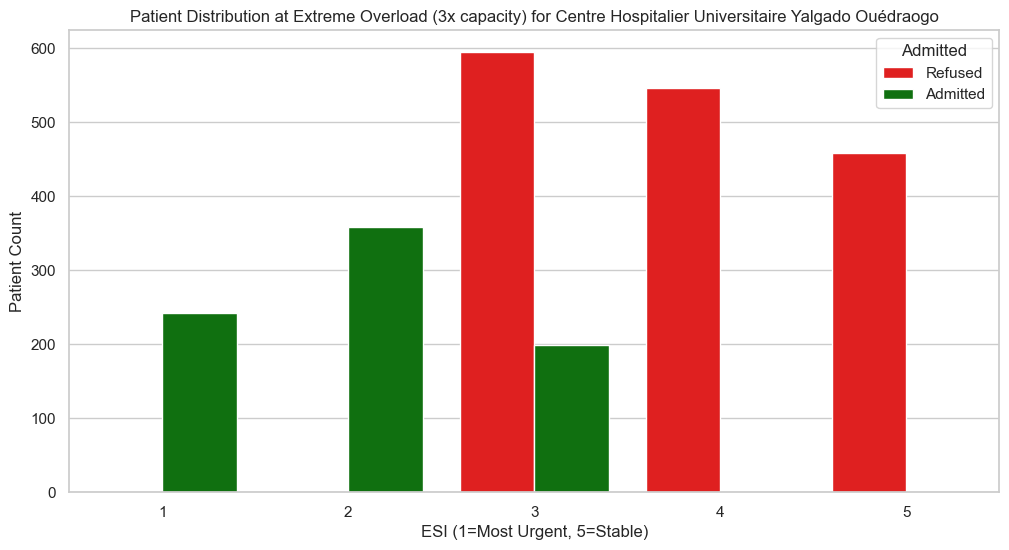

C:\Users\HP\AppData\Local\Temp\ipykernel_40604\657977558.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=admission_rates_overload, x='ESI', y='Admission Rate', palette='RdYlGn_r')


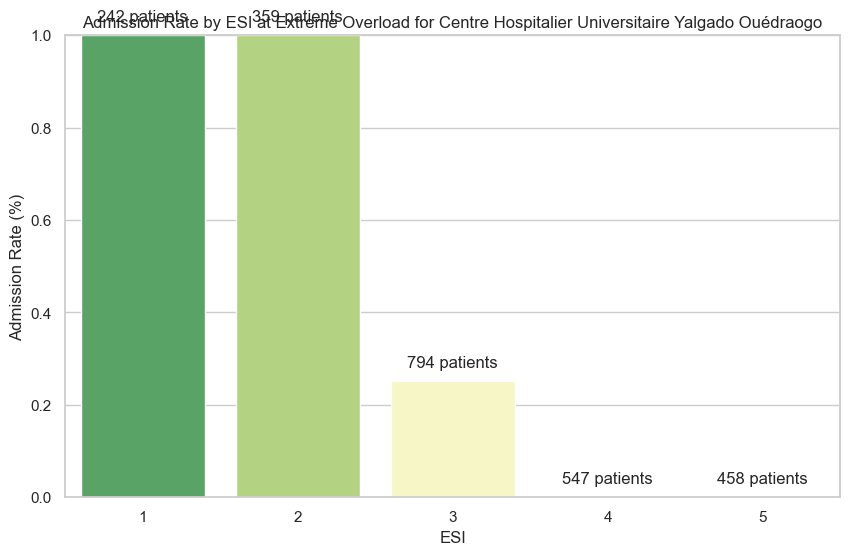

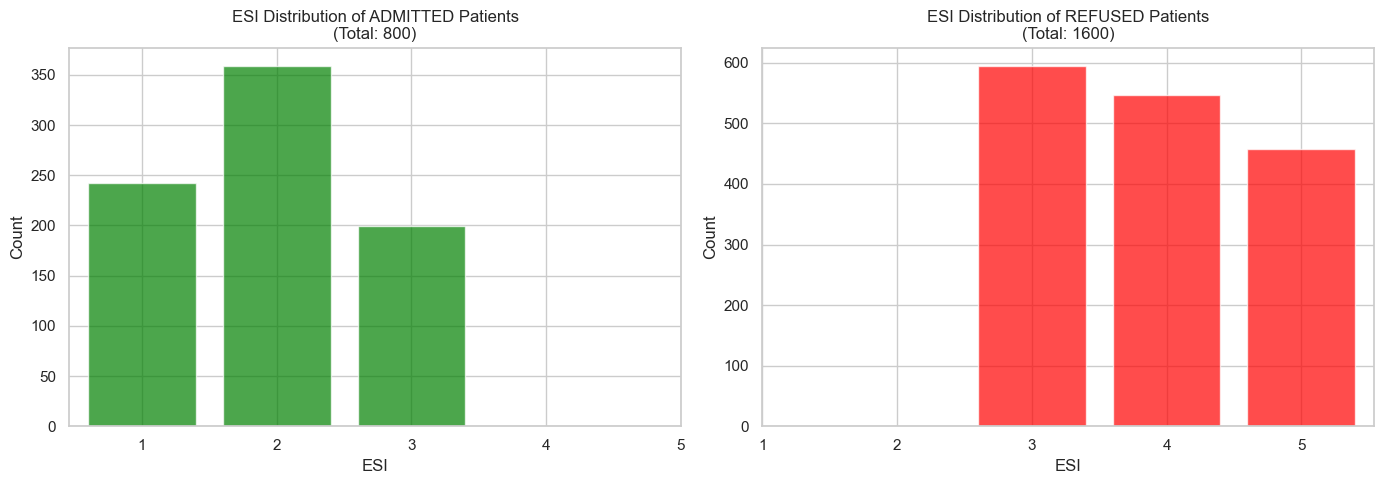

=== OVERLOAD EVALUATION RESULTS ===
- Total Patients: 2400
- Admitted Patients: 800
- Admission Rate (%): 33.333
- Average ESI (Admitted): 1.946
- Average ESI (Refused): 3.914
- ESI 1 Admission Rate: 1.000
- ESI 5 Admission Rate: 0.000
- Weighted Priority Score: 3243


In [27]:
# Overload scenario: load patients far exceeding hospital capacity
overload_batch = patients_df.sample(int(capacity * 3), replace=True)  # 3x hospital capacity
overload_assignments = solve_single_hospital_allocation(overload_batch, int(capacity))

overload_admission_results = []
for i in range(len(overload_batch)):
    admitted = value(overload_assignments[i]) == 1
    overload_admission_results.append({"ESI": overload_batch.iloc[i]['ESI'], "Admitted": admitted})

overload_res_df = pd.DataFrame(overload_admission_results)

print(f'\n=== OVERLOAD SCENARIO ===')
print(f'Total patients loaded: {len(overload_res_df)}')
print(f'Hospital capacity: {int(capacity)} beds')
print(f'Overload ratio: {len(overload_res_df) / int(capacity):.2f}x hospital capacity')
print(f'Admitted: {overload_res_df["Admitted"].sum()}')
print(f'Refused: {(~overload_res_df["Admitted"]).sum()}\n')

# Graph 1: Admitted vs Refused by ESI
plt.figure(figsize=(12, 6))
sns.countplot(data=overload_res_df, x='ESI', hue='Admitted', palette={True: "green", False: "red"})
plt.title(f'Patient Distribution at Extreme Overload (3x capacity) for {hospital_name}')
plt.xlabel('ESI (1=Most Urgent, 5=Stable)')
plt.ylabel('Patient Count')
plt.legend(title='Admitted', labels=['Refused', 'Admitted'])
plt.show()

# Graph 2: Admission rate by ESI
admission_rates_overload = overload_res_df.groupby('ESI')['Admitted'].agg(['mean', 'count']).reset_index()
admission_rates_overload.columns = ['ESI', 'Admission Rate', 'Total']

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=admission_rates_overload, x='ESI', y='Admission Rate', palette='RdYlGn_r')
plt.title(f'Admission Rate by ESI at Extreme Overload for {hospital_name}')
plt.xlabel('ESI')
plt.ylabel('Admission Rate (%)')
plt.ylim(0, 1)
# Add count labels on bars
for i, v in enumerate(admission_rates_overload['Admission Rate']):
    ax.text(i, v + 0.03, f'{int(admission_rates_overload.iloc[i]["Total"])} patients', ha='center')
plt.show()

# Graph 3: ESI distribution of admitted vs refused
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Admitted patients ESI distribution
admitted_esi = overload_res_df[overload_res_df['Admitted']]['ESI'].value_counts().sort_index()
axes[0].bar(admitted_esi.index, admitted_esi.values, color='green', alpha=0.7)
axes[0].set_title(f'ESI Distribution of ADMITTED Patients\n(Total: {admitted_esi.sum()})')
axes[0].set_xlabel('ESI')
axes[0].set_ylabel('Count')
axes[0].set_xticks([1, 2, 3, 4, 5])

# Refused patients ESI distribution
refused_esi = overload_res_df[~overload_res_df['Admitted']]['ESI'].value_counts().sort_index()
axes[1].bar(refused_esi.index, refused_esi.values, color='red', alpha=0.7)
axes[1].set_title(f'ESI Distribution of REFUSED Patients\n(Total: {refused_esi.sum()})')
axes[1].set_xlabel('ESI')
axes[1].set_ylabel('Count')
axes[1].set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

# Evaluation metrics
overload_metrics = {
    'Total Patients': len(overload_res_df),
    'Admitted Patients': overload_res_df['Admitted'].sum(),
    'Admission Rate (%)': (overload_res_df['Admitted'].mean() * 100),
    'Average ESI (Admitted)': overload_res_df[overload_res_df['Admitted']]['ESI'].mean(),
    'Average ESI (Refused)': overload_res_df[~overload_res_df['Admitted']]['ESI'].mean(),
    'ESI 1 Admission Rate': overload_res_df[overload_res_df['ESI'] == 1]['Admitted'].mean(),
    'ESI 5 Admission Rate': overload_res_df[overload_res_df['ESI'] == 5]['Admitted'].mean(),
    'Weighted Priority Score': overload_res_df[overload_res_df['Admitted']]['ESI'].apply(lambda x: 6 - x).sum(),
}

print('=== OVERLOAD EVALUATION RESULTS ===')
for k, v in overload_metrics.items():
    if 'Rate' in k or 'Average' in k:
        print(f'- {k}: {v:.3f}')
    else:
        print(f'- {k}: {v}')

## 6. Overload Scenario: Extreme Surcharge
In this scenario, we load a massive number of patients (far exceeding hospital capacity) to observe how the Linear Programming model prioritizes admissions.

- **Patients loaded**: significantly more than hospital capacity.
- **Goal**: Observe if the model prioritizes urgent cases (low ESI) over stable cases (high ESI).
- **Key insight**: Under extreme overload, the model should admit only the highest-priority patients and refuse lower-priority ones.


=== OVERLOAD SCENARIO ===
Total patients loaded: 2400
Hospital capacity: 800 beds
Overload ratio: 3.00x hospital capacity
Admitted: 800
Refused: 1600



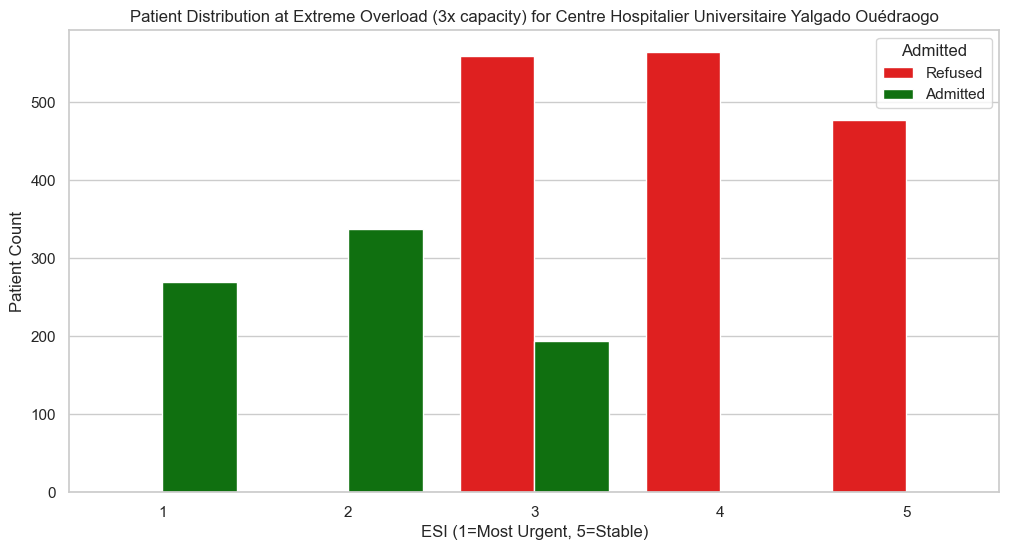

C:\Users\HP\AppData\Local\Temp\ipykernel_40604\657977558.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=admission_rates_overload, x='ESI', y='Admission Rate', palette='RdYlGn_r')


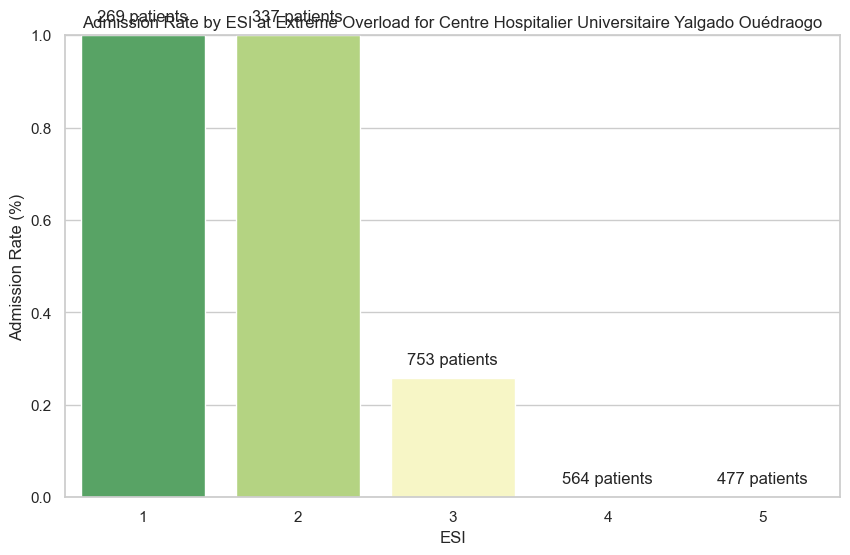

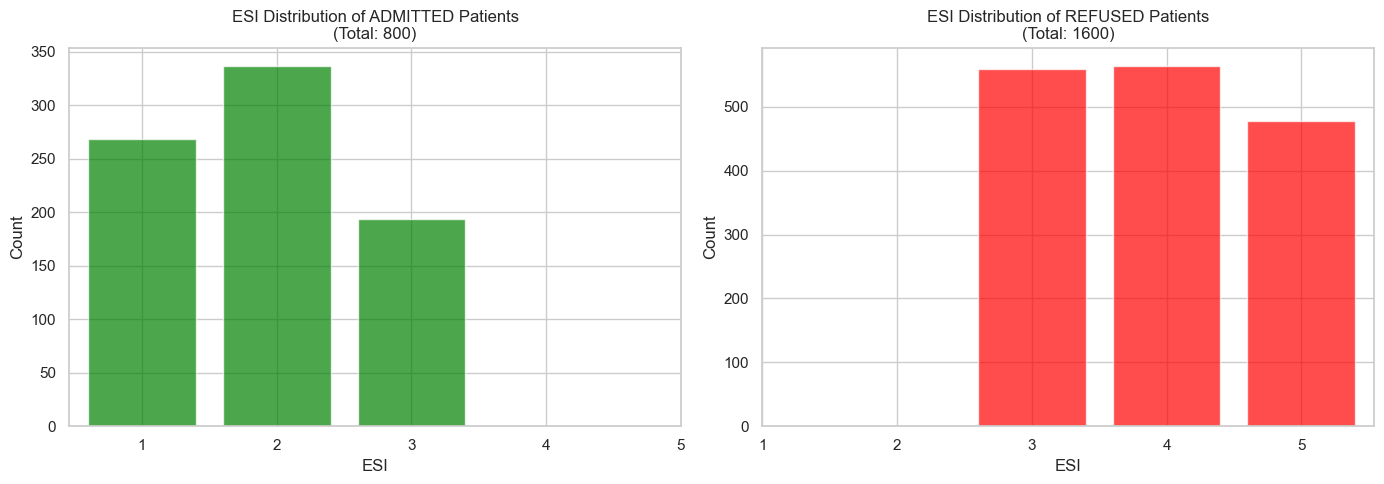

=== OVERLOAD EVALUATION RESULTS ===
- Total Patients: 2400
- Admitted Patients: 800
- Admission Rate (%): 33.333
- Average ESI (Admitted): 1.906
- Average ESI (Refused): 3.949
- ESI 1 Admission Rate: 1.000
- ESI 5 Admission Rate: 0.000
- Weighted Priority Score: 3275


In [28]:
# Overload scenario: load patients far exceeding hospital capacity
overload_batch = patients_df.sample(int(capacity * 3), replace=True)  # 3x hospital capacity
overload_assignments = solve_single_hospital_allocation(overload_batch, int(capacity))

overload_admission_results = []
for i in range(len(overload_batch)):
    admitted = value(overload_assignments[i]) == 1
    overload_admission_results.append({"ESI": overload_batch.iloc[i]['ESI'], "Admitted": admitted})

overload_res_df = pd.DataFrame(overload_admission_results)

print(f'\n=== OVERLOAD SCENARIO ===')
print(f'Total patients loaded: {len(overload_res_df)}')
print(f'Hospital capacity: {int(capacity)} beds')
print(f'Overload ratio: {len(overload_res_df) / int(capacity):.2f}x hospital capacity')
print(f'Admitted: {overload_res_df["Admitted"].sum()}')
print(f'Refused: {(~overload_res_df["Admitted"]).sum()}\n')

# Graph 1: Admitted vs Refused by ESI
plt.figure(figsize=(12, 6))
sns.countplot(data=overload_res_df, x='ESI', hue='Admitted', palette={True: "green", False: "red"})
plt.title(f'Patient Distribution at Extreme Overload (3x capacity) for {hospital_name}')
plt.xlabel('ESI (1=Most Urgent, 5=Stable)')
plt.ylabel('Patient Count')
plt.legend(title='Admitted', labels=['Refused', 'Admitted'])
plt.show()

# Graph 2: Admission rate by ESI
admission_rates_overload = overload_res_df.groupby('ESI')['Admitted'].agg(['mean', 'count']).reset_index()
admission_rates_overload.columns = ['ESI', 'Admission Rate', 'Total']

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=admission_rates_overload, x='ESI', y='Admission Rate', palette='RdYlGn_r')
plt.title(f'Admission Rate by ESI at Extreme Overload for {hospital_name}')
plt.xlabel('ESI')
plt.ylabel('Admission Rate (%)')
plt.ylim(0, 1)
# Add count labels on bars
for i, v in enumerate(admission_rates_overload['Admission Rate']):
    ax.text(i, v + 0.03, f'{int(admission_rates_overload.iloc[i]["Total"])} patients', ha='center')
plt.show()

# Graph 3: ESI distribution of admitted vs refused
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Admitted patients ESI distribution
admitted_esi = overload_res_df[overload_res_df['Admitted']]['ESI'].value_counts().sort_index()
axes[0].bar(admitted_esi.index, admitted_esi.values, color='green', alpha=0.7)
axes[0].set_title(f'ESI Distribution of ADMITTED Patients\n(Total: {admitted_esi.sum()})')
axes[0].set_xlabel('ESI')
axes[0].set_ylabel('Count')
axes[0].set_xticks([1, 2, 3, 4, 5])

# Refused patients ESI distribution
refused_esi = overload_res_df[~overload_res_df['Admitted']]['ESI'].value_counts().sort_index()
axes[1].bar(refused_esi.index, refused_esi.values, color='red', alpha=0.7)
axes[1].set_title(f'ESI Distribution of REFUSED Patients\n(Total: {refused_esi.sum()})')
axes[1].set_xlabel('ESI')
axes[1].set_ylabel('Count')
axes[1].set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

# Evaluation metrics
overload_metrics = {
    'Total Patients': len(overload_res_df),
    'Admitted Patients': overload_res_df['Admitted'].sum(),
    'Admission Rate (%)': (overload_res_df['Admitted'].mean() * 100),
    'Average ESI (Admitted)': overload_res_df[overload_res_df['Admitted']]['ESI'].mean(),
    'Average ESI (Refused)': overload_res_df[~overload_res_df['Admitted']]['ESI'].mean(),
    'ESI 1 Admission Rate': overload_res_df[overload_res_df['ESI'] == 1]['Admitted'].mean(),
    'ESI 5 Admission Rate': overload_res_df[overload_res_df['ESI'] == 5]['Admitted'].mean(),
    'Weighted Priority Score': overload_res_df[overload_res_df['Admitted']]['ESI'].apply(lambda x: 6 - x).sum(),
}

print('=== OVERLOAD EVALUATION RESULTS ===')
for k, v in overload_metrics.items():
    if 'Rate' in k or 'Average' in k:
        print(f'- {k}: {v:.3f}')
    else:
        print(f'- {k}: {v}')